### Seaborn

- Provides a layer of abstraction hence simpler to use
- better aesthetics
- more graphs included

### Readomap

Types of Functions
- Figure Level
- Axis Level

Main Classifications
- Relational Plot: Scatter Plot / Line plot
- Distribution Plot: Histogram / Kde Plot
- Categorical Plot: Bar plot / Countplot / Box plot 
- Matrix Plot: Heatmap / Cluster map
- Regression Plot:  
- Multiplots: Join Plot / Pair Plot

### Relational Plot

- Scatter plot

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# Load dataset
tips = px.data.tips()

<Axes: xlabel='total_bill', ylabel='tip'>

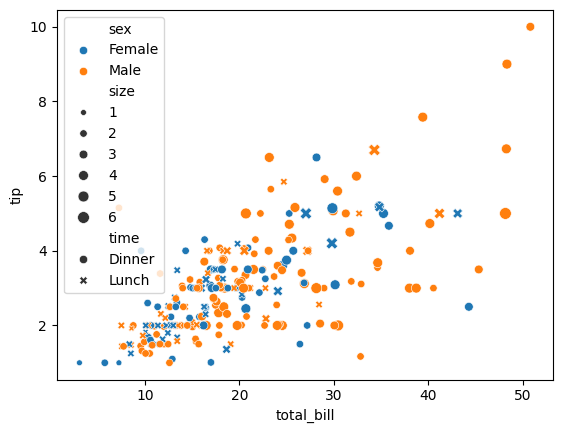

In [3]:
import seaborn as sns
# scatter is a axis level function, it is used to plot the data points on the graph
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex',style='time',size='size')

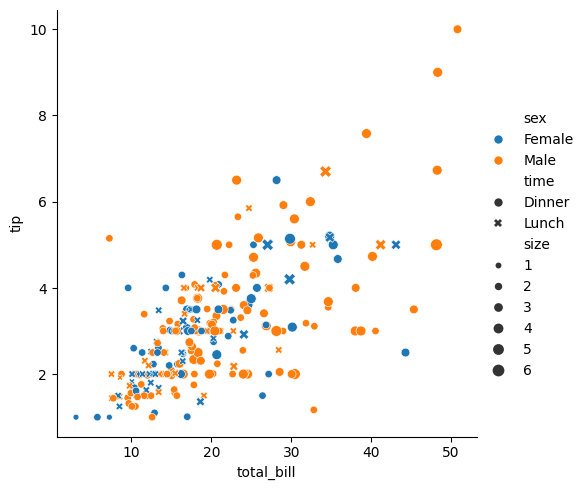

In [4]:
# rel plot is a figure level function, it is used to plot the data points on the graph
sns.relplot(data=tips, x='total_bill', y='tip', kind='scatter', hue='sex',style='time', size='size')

### Line Plot

In [5]:
gap=px.data.gapminder()

<Axes: xlabel='year', ylabel='lifeExp'>

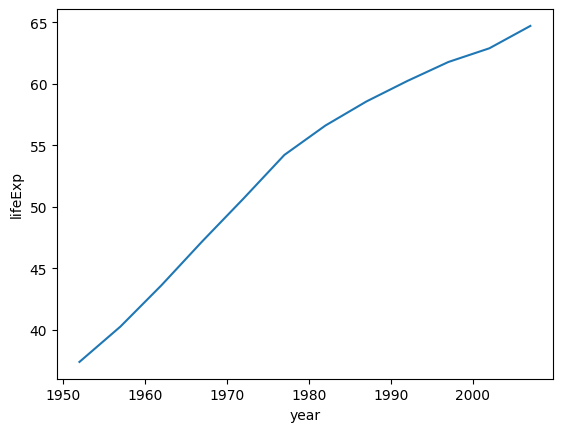

In [6]:
temp_df=gap[gap['country']=='India']
sns.lineplot(data=temp_df, x='year', y='lifeExp')

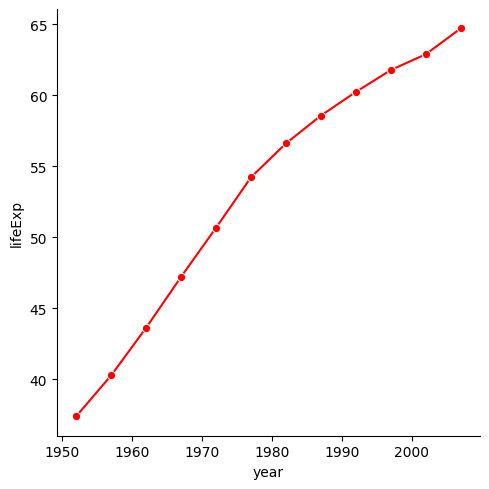

In [7]:
sns.relplot(data=temp_df, x='year', y='lifeExp', kind='line',marker='o',color='red')

In [8]:
# hue -> style
temp_df=gap[gap['country'].isin(['India','Pakistan','China'])]

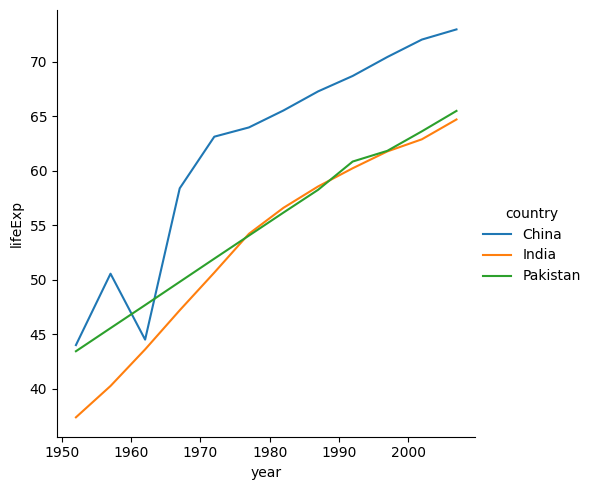

In [9]:
sns.relplot(data=temp_df, x='year', y='lifeExp', kind='line' ,hue='country')

<Axes: xlabel='year', ylabel='lifeExp'>

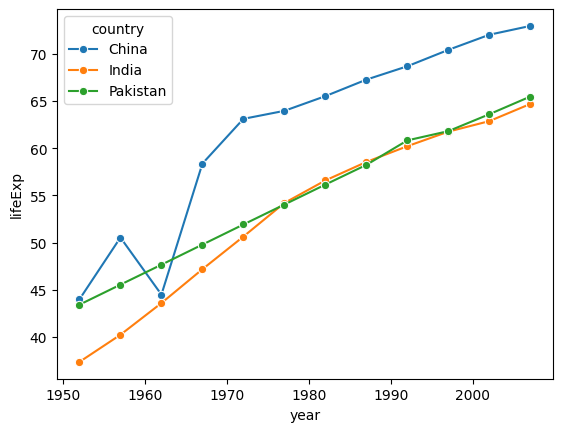

In [10]:
sns.lineplot(data=temp_df, x='year', y='lifeExp',hue='country',marker='o')

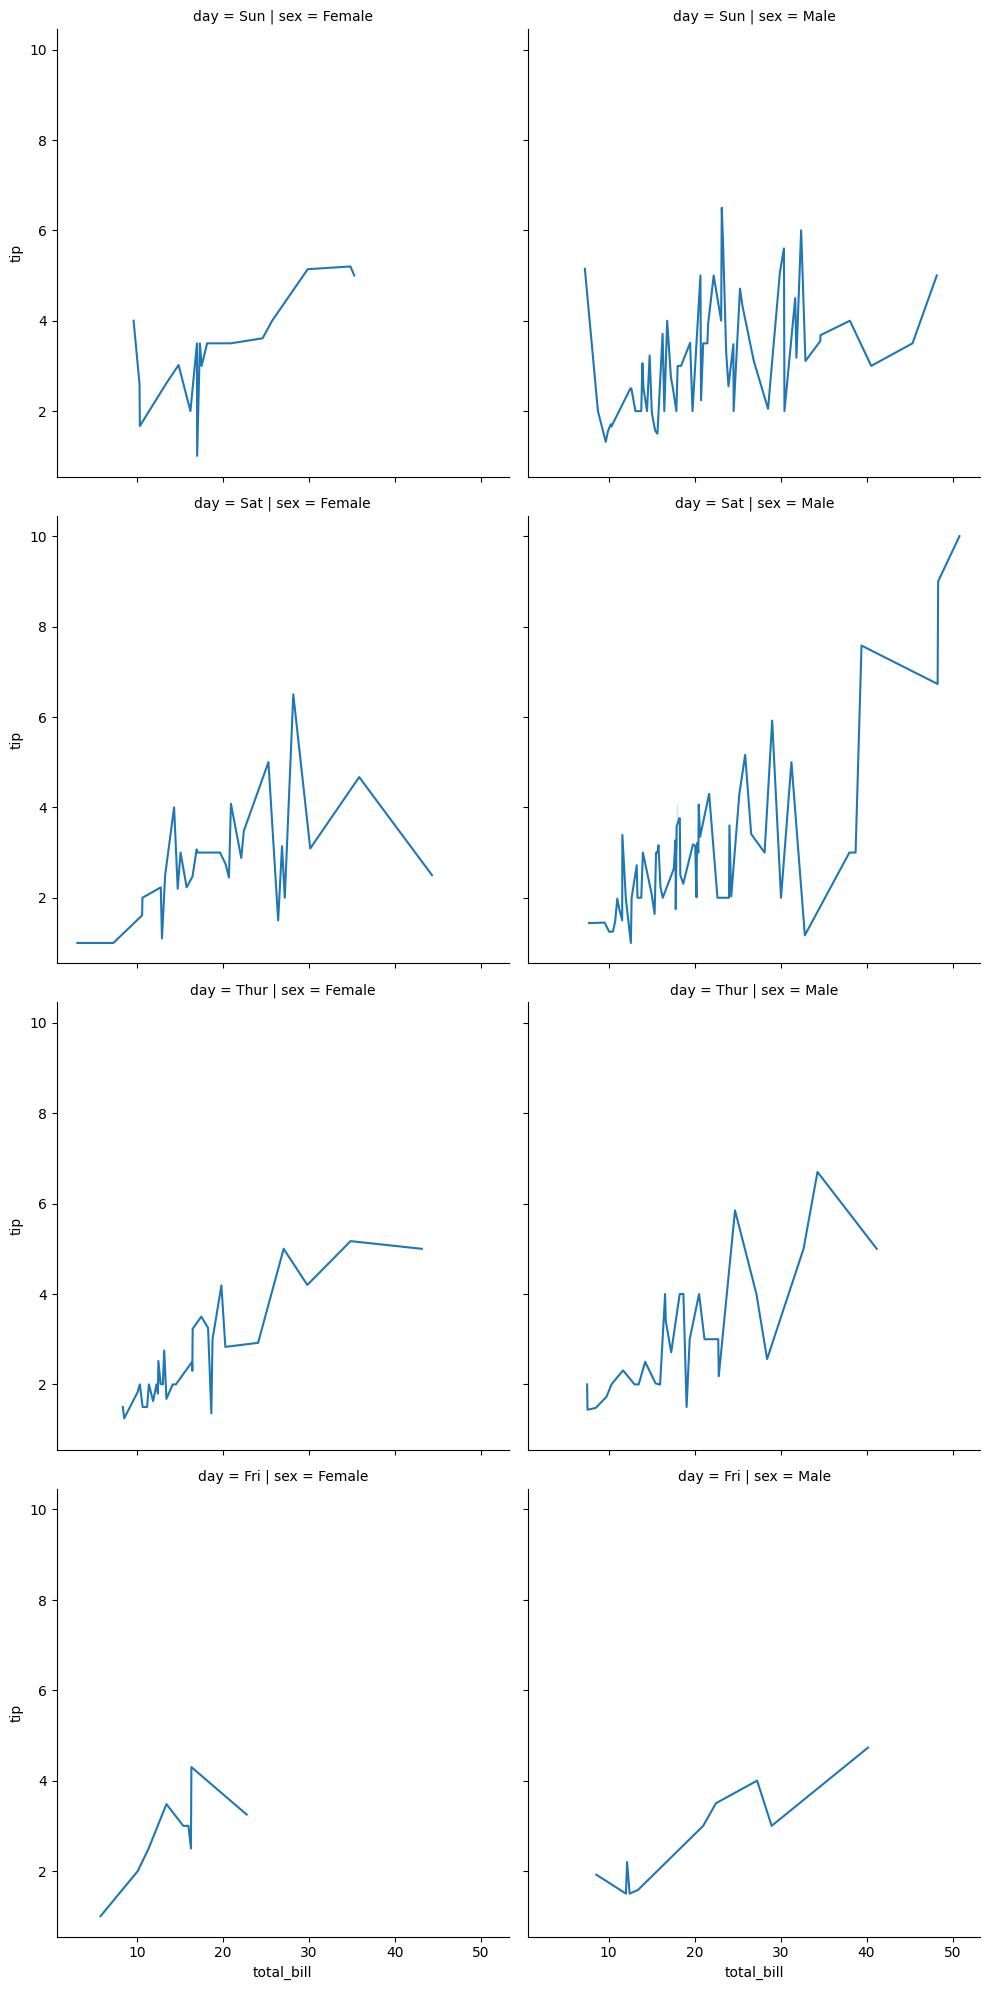

In [11]:
# Facet Plot -> work only figure level function 
sns.relplot(data=tips,x='total_bill', y='tip' ,kind='line', col='sex',row='day')

- col Wrap

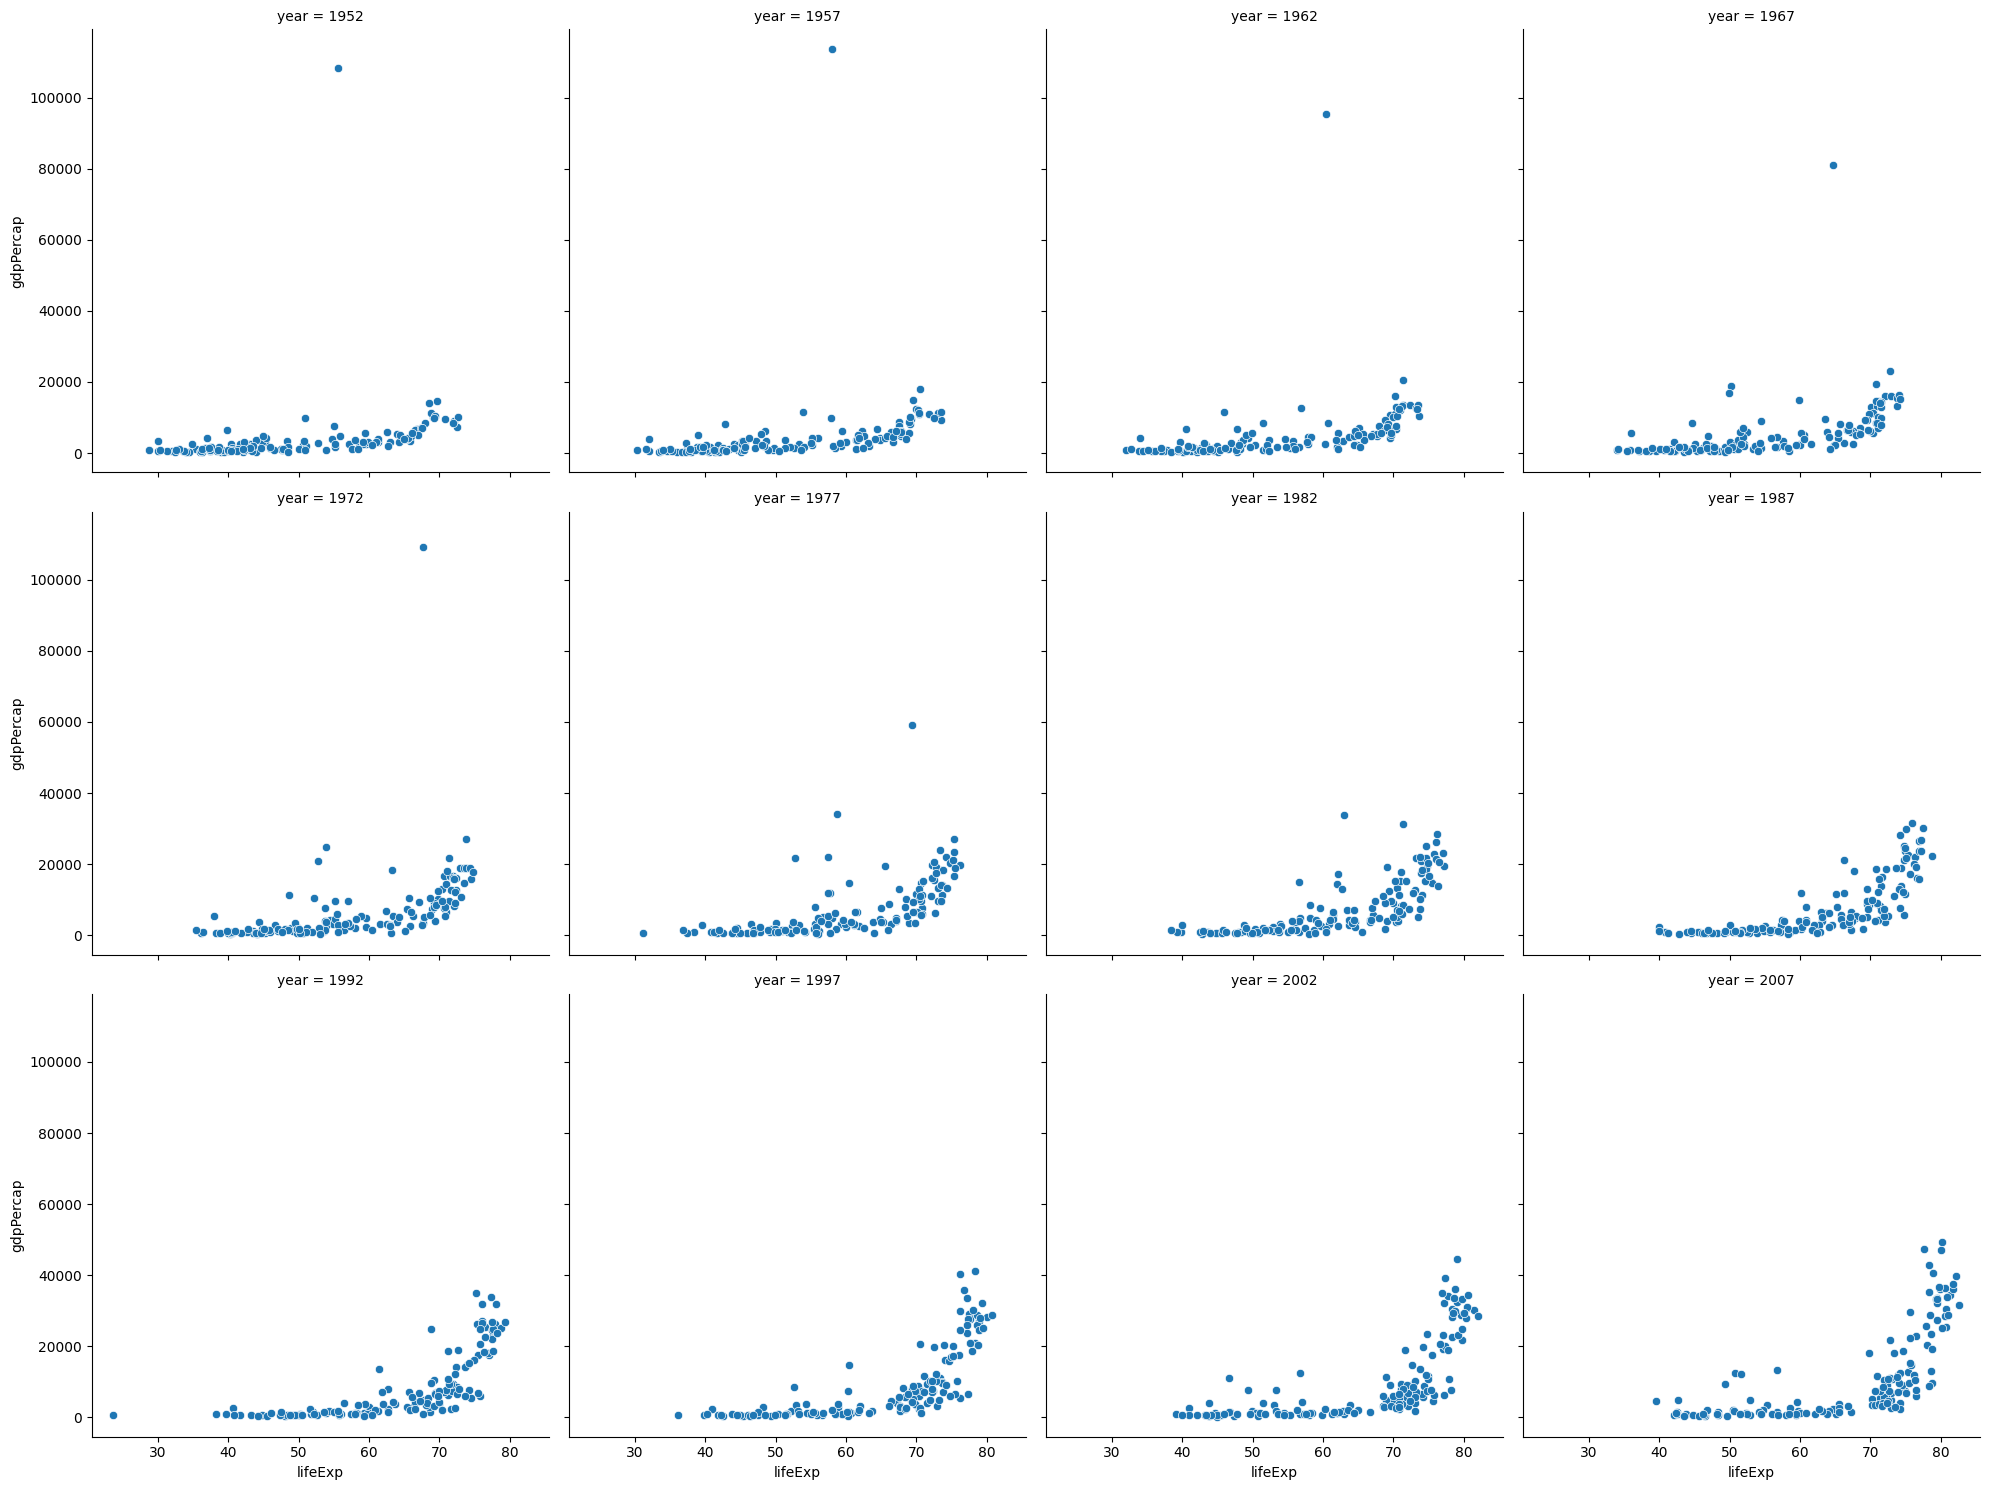

In [12]:
sns.relplot(data=gap, x='lifeExp', y='gdpPercap',kind='scatter',col='year', col_wrap=4)

### Distribution Plots

- used for univariant analysis
- used to find out distribution
- Range of observation
- Central Tendency
- is the data bimodal?
- Are there outliers

- histplot

In [13]:
# figure level -> displot
# axis level -> histplot-> kdeplot -> rugplot

<Axes: xlabel='total_bill', ylabel='Count'>

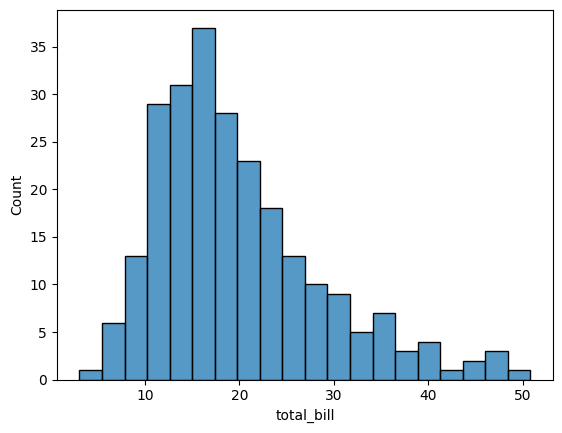

In [14]:
# plotting univariant histogram
sns.histplot(data=tips, x='total_bill',bins=20)

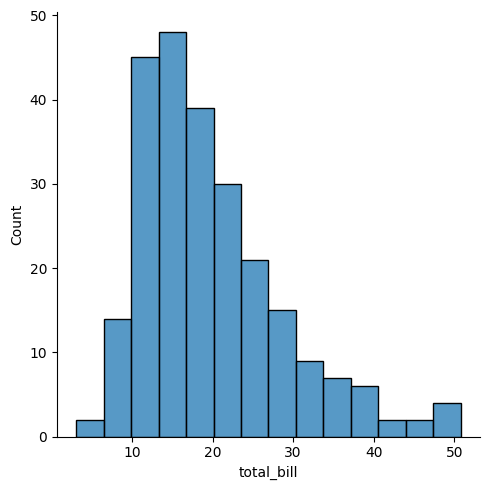

In [15]:
sns.displot(data=tips,x='total_bill',kind='hist')

In [ ]:
# hue parameter
sns.displot(data=tips,x='tip',kind='hist',hue='sex')

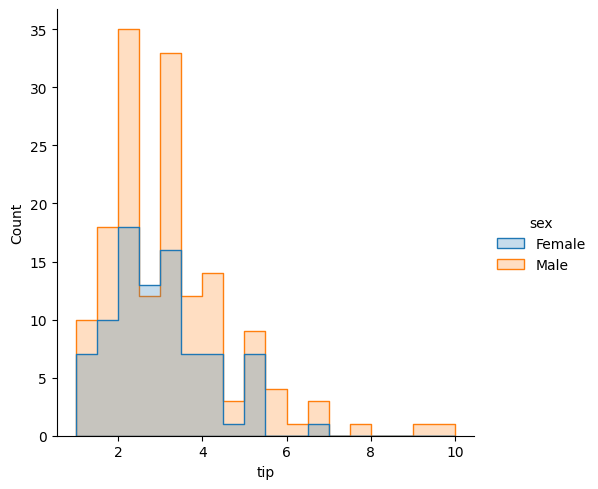

In [ ]:
# element parameter
sns.displot(data=tips,x='tip',kind='hist',hue='sex',element='step')

In [ ]:
titanic=sns.load_dataset('titanic')

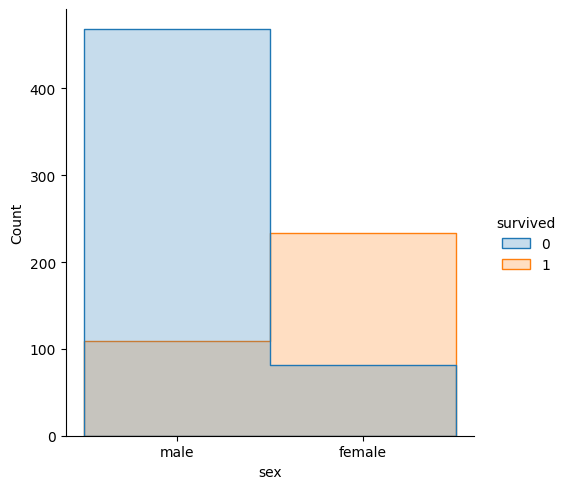

In [ ]:
sns.displot(data=titanic,x='sex',kind='hist',element='step',hue='survived')

- Kdeplot

In [ ]:
# rather than using displot bins, a KDE plot can be used to visualize the distribution of a continuous variable. KDE stands for Kernel Density Estimation, which is a way to estimate the probability density function of a random variable. It provides a smooth curve that represents the distribution of the data.

<Axes: xlabel='total_bill', ylabel='Density'>

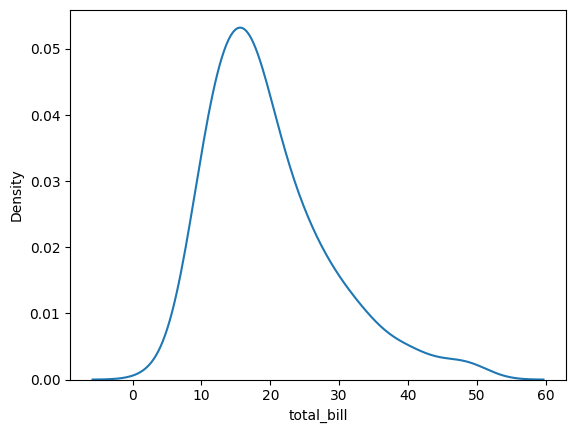

In [ ]:
sns.kdeplot(data=tips,x='total_bill')

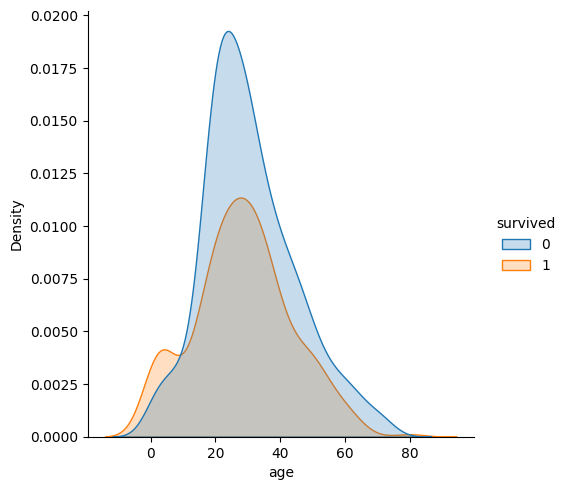

In [ ]:
plt.figure(figsize=(10,6))
sns.displot(data=titanic,x='age',kind='kde',hue='survived',fill=True)

- rugplot

<Axes: xlabel='total_bill'>

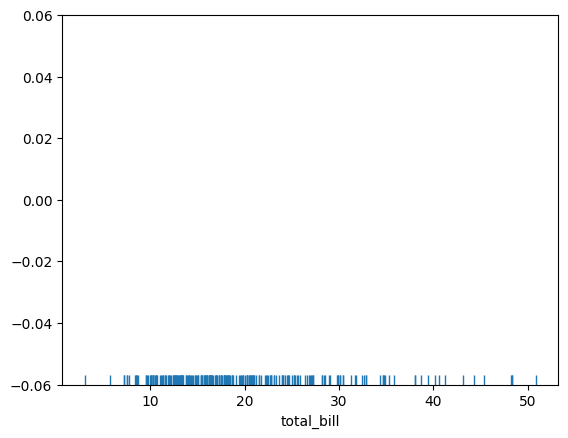

In [ ]:
sns.rugplot(data=tips,x='total_bill')

<Axes: xlabel='age', ylabel='fare'>

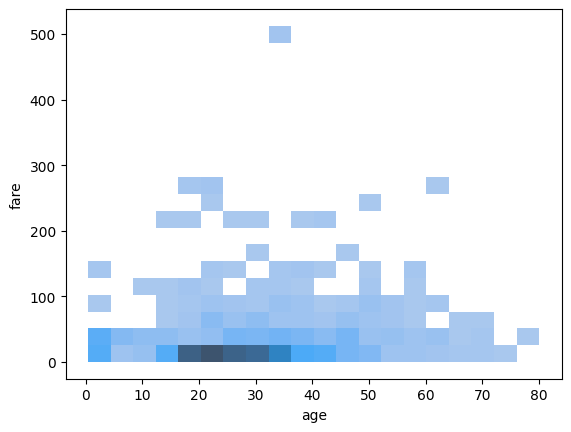

In [ ]:
# # bivarint histogram
sns.histplot(data=titanic,x='age',y='fare',bins=20)
# titanic.head()

### 2. Matrix Plot

- Heat map

<Axes: xlabel='year', ylabel='country'>

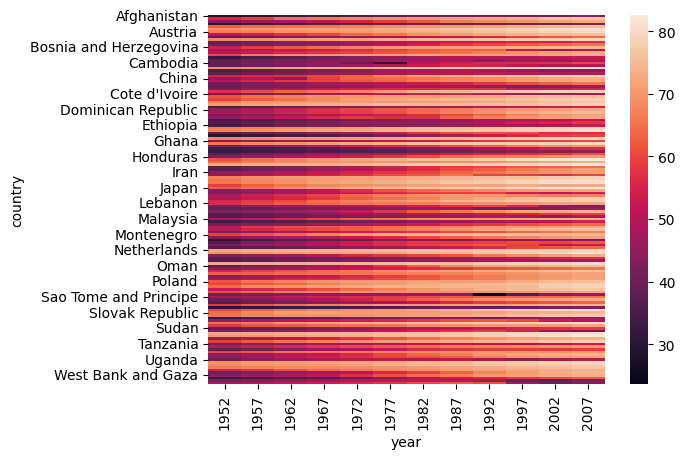

In [ ]:
# Heat map
gap_pivot=gap.pivot_table(index='country',columns='year',values='lifeExp',aggfunc='mean')
sns.heatmap(data=gap_pivot)

<Axes: xlabel='year', ylabel='country'>

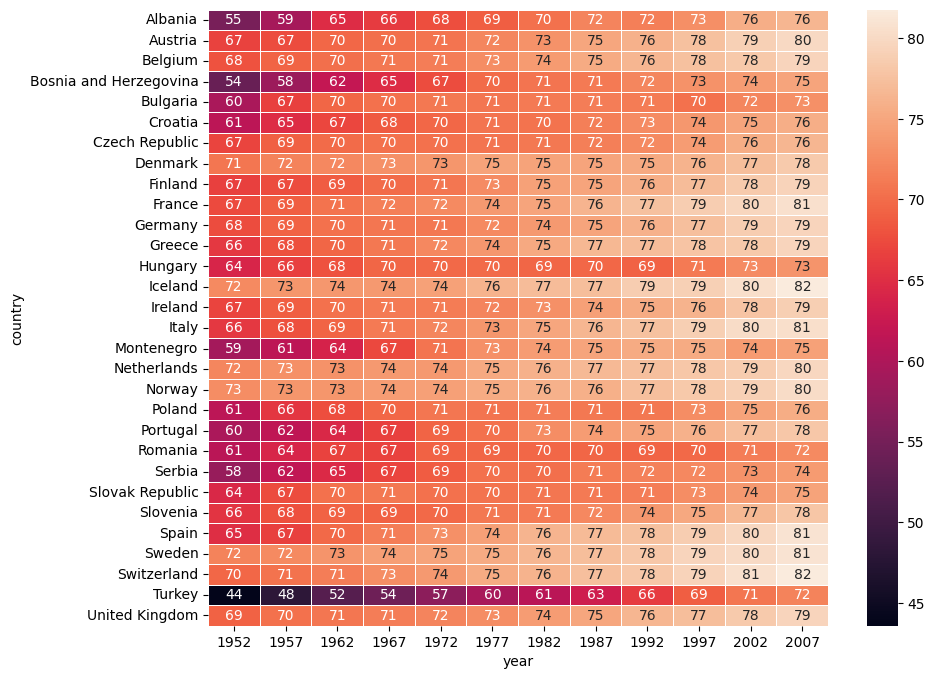

In [ ]:
# annot
gap_pivot=gap[gap['continent']== 'Europe'].pivot_table(index='country',columns='year',values='lifeExp',aggfunc='mean')
plt.figure(figsize=(10,8))
sns.heatmap(data=gap_pivot, annot=True,linewidths=0.5)

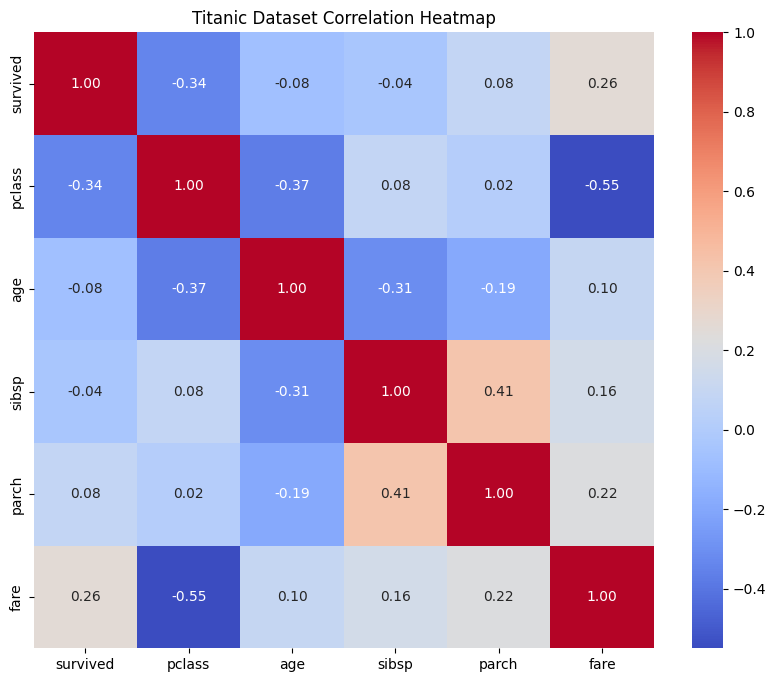

In [ ]:
titanicnumeric_df = titanic.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(
    titanicnumeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Titanic Dataset Correlation Heatmap')
plt.show()

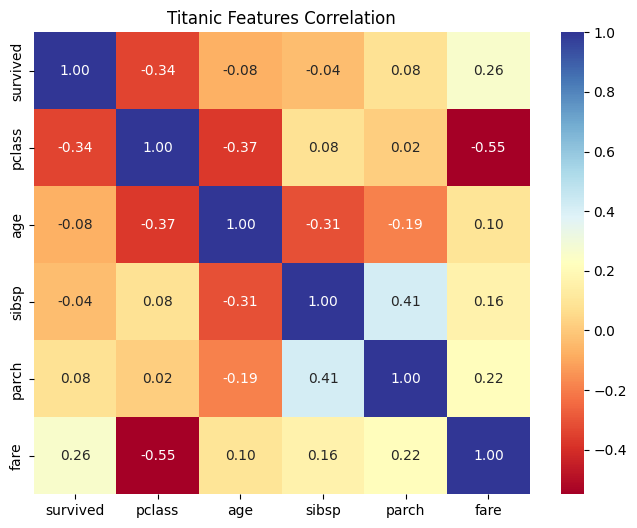

In [ ]:
cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

plt.figure(figsize=(8,6))
sns.heatmap(
    titanic[cols].corr(),
    annot=True,
    cmap='RdYlBu',
    fmt='.2f'
)

plt.title('Titanic Features Correlation')
plt.show()

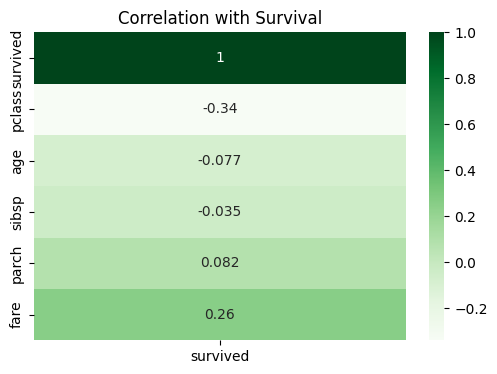

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    titanic[['survived','pclass','age','sibsp','parch','fare']].corr()[['survived']],
    annot=True,
    cmap='Greens'
)

plt.title('Correlation with Survival')
plt.show()

- Clustermap

In [ ]:
iris=px.data.iris()
iris

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,3
146,6.3,2.5,5.0,1.9,virginica,3
147,6.5,3.0,5.2,2.0,virginica,3
148,6.2,3.4,5.4,2.3,virginica,3


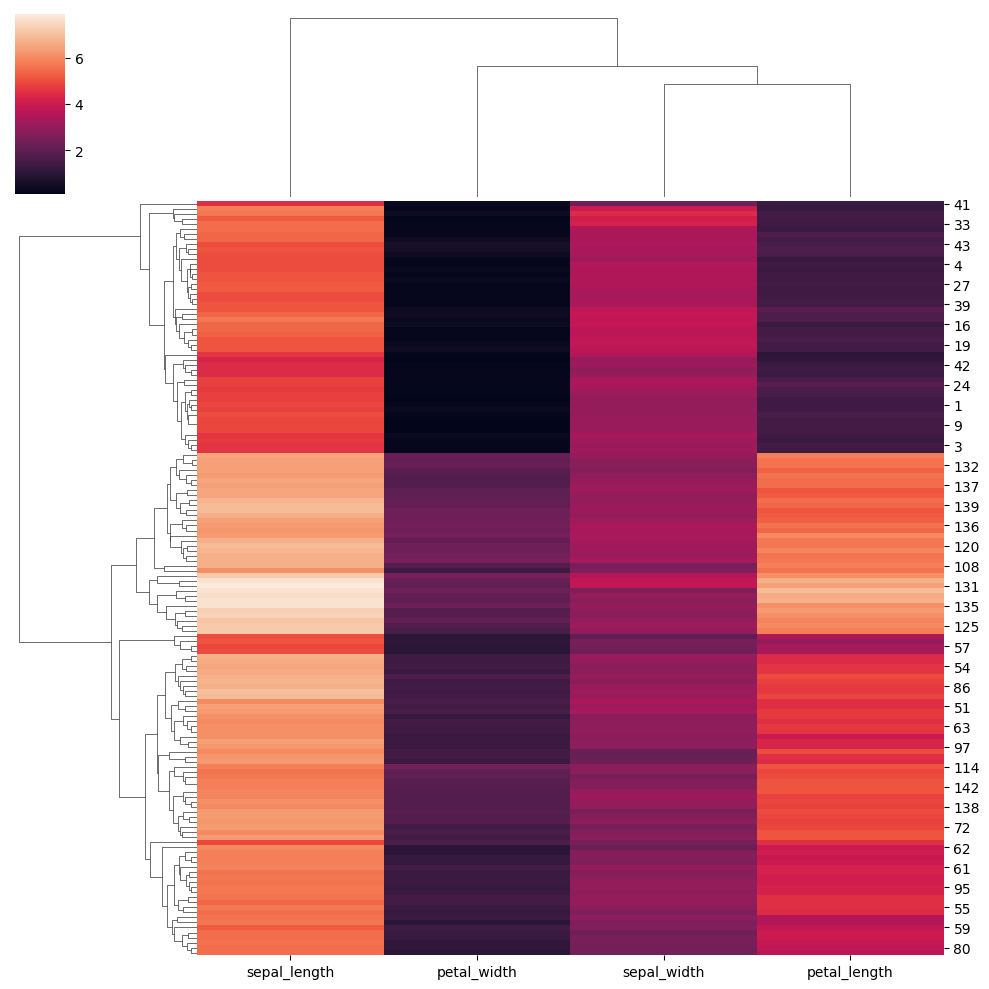

In [ ]:
sns.clustermap(iris.iloc[:,[0,1,2,3]])